<a href="https://colab.research.google.com/github/tannialhernandez/topicosAvanzadosAnalitica/blob/main/E6-RNN_LSTM_GRU/E6_RNN_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 6

## Predict rating using LSTM


In [ ]:
!pip install livelossplot

In [131]:
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from collections import Counter
import re
from wordcloud import WordCloud
from collections import Counter
import numpy as np
from sklearn.model_selection import KFold
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Embedding, SimpleRNN, Dropout, BatchNormalization, Bidirectional, LSTM, Conv1D, MaxPooling1D,Flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.regularizers import l1_l2
from livelossplot import PlotLossesKeras
%matplotlib inline



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [132]:
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)

In [133]:
plots = dataTraining['plot']
y = (dataTraining['rating'] >= dataTraining['rating'].mean()).astype(int)

In [134]:
plots

,plot
3107,most is the story of a single father who takes...
900,a serial killer decides to teach the secrets o...
6724,"in sweden , a female blackmailer with a disfi..."
4704,"in a friday afternoon in new york , the presi..."
2582,"in los angeles , the editor of a publishing h..."
...,...
8417,""" our marriage , their wedding . "" it ' s l..."
1592,"the wandering barbarian , conan , alongside ..."
1723,"like a tale spun by scheherazade , kismet fol..."
7605,"mrs . brisby , a widowed mouse , lives in a..."


In [135]:
y

,rating
3107,1
900,0
6724,1
4704,1
2582,1
...,...
8417,0
1592,0
1723,0
7605,1


In [136]:
def exploratorio_plots_listas(plots_lista, y_lista):
    import pandas as pd
    import matplotlib.pyplot as plt
    import re
    from collections import Counter
    from wordcloud import WordCloud

    df_analisis = pd.DataFrame({'textos': plots_lista})
    y_df = pd.DataFrame({'rating': y_lista})

    if isinstance(df_analisis['textos'].iloc[0], list):
        df_analisis['textos'] = df_analisis['textos'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

    df_analisis['plot_length'] = df_analisis['textos'].apply(len)
    print(df_analisis['plot_length'].describe())

    plt.hist(df_analisis['plot_length'], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribución de la longitud de los textos')
    plt.xlabel('Longitud del texto')
    plt.ylabel('Frecuencia')
    plt.show()

    all_text = ' '.join(df_analisis['textos'])
    all_text_cleaned = re.sub(r'[^a-zA-Z\s]', '', all_text.lower())
    word_counts = Counter(all_text_cleaned.split())
    most_common_words = word_counts.most_common(10)
    words, frequencies = zip(*most_common_words)

    plt.figure(figsize=(10, 6))
    plt.bar(words, frequencies, color='skyblue', edgecolor='black')
    plt.title('Las 10 palabras más comunes')
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.show()

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nube de palabras')
    plt.show()

    print(f"Proporción de clases balanceadas en 'rating': {y_df['rating'].value_counts() / len(y_df)}")
    print(f"Longitud media de los textos: {df_analisis['plot_length'].mean():.2f}")
    print(f"Desviación estándar de la longitud: {df_analisis['plot_length'].std():.2f}")

    return None

count    7895.000000
mean      748.820899
std       494.766799
min         3.000000
25%       412.000000
50%       655.000000
75%       951.500000
max      9408.000000
Name: plot_length, dtype: float64


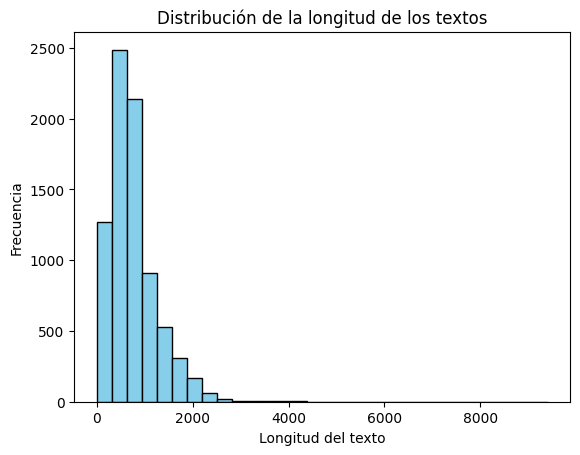

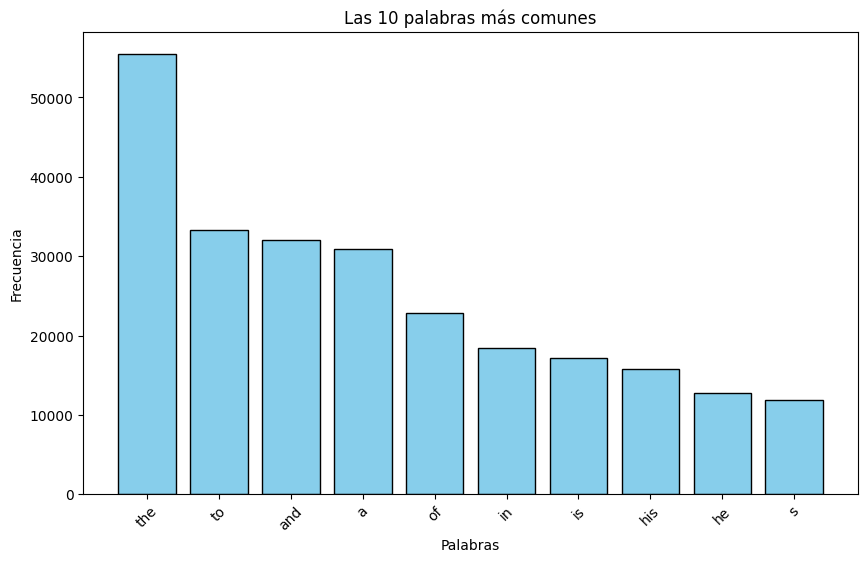

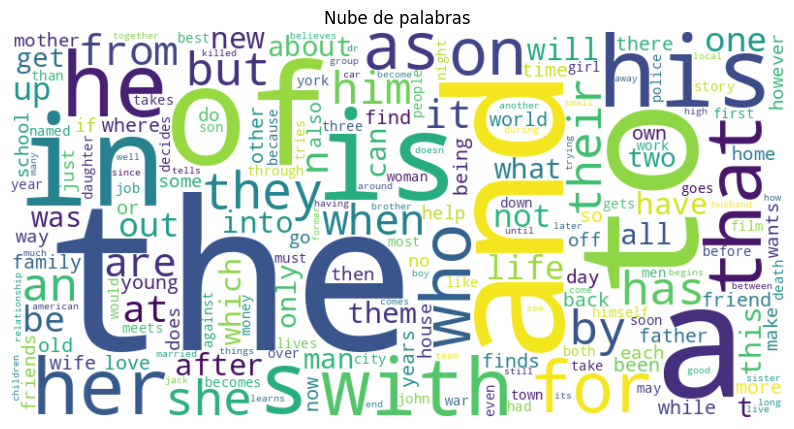

Proporción de clases balanceadas en 'rating': rating
1    0.528436
0    0.471564
Name: count, dtype: float64
Longitud media de los textos: 748.82
Desviación estándar de la longitud: 494.77


In [137]:
exploratorio_plots_listas(plots,y)

# Exercise 6.1

- Remove stopwords
- Lowercase
- split the text in words
- pad_sequences

In [200]:
def preprocess_and_split_listas(texts, labels, max_features=10000, max_len=150, test_size=0.2, random_state=42):
   if isinstance(texts, pd.Series) or isinstance(texts, pd.DataFrame):
       texts = texts.values.flatten().tolist()
   elif not isinstance(texts, list):
       texts = [texts]
   if isinstance(labels, pd.Series) or isinstance(labels, pd.DataFrame):
       labels = labels.values.flatten().tolist()
   elif not isinstance(labels, list):
       labels = [labels]
   stop_words = set(stopwords.words('english'))
   def clean_text(text):
       if not isinstance(text, str):
           text = str(text)
       text = re.sub(r'\s+', ' ', text.strip())
       text = re.sub(r'[^a-zA-Z\s]', '', text)
       text = text.lower()
       words = word_tokenize(text)
       filtered_words = [word for word in words if word not in stop_words and word != '' and len(word) > 1]
       return ' '.join(filtered_words)

   cleaned_texts = [clean_text(text) for text in texts]

   text_lengths = [len(text.split()) for text in cleaned_texts]
   text_lengths_series = pd.Series(text_lengths)

   print("Estadísticas descriptivas de longitud de textos (después de preprocesamiento):")
   stats = text_lengths_series.describe()
   print(f"count {stats['count']:.0f}")
   print(f"mean  {stats['mean']:.2f}")
   print(f"std   {stats['std']:.2f}")
   print(f"min   {stats['min']:.0f}")
   print(f"25%   {stats['25%']:.0f}")
   print(f"50%   {stats['50%']:.0f}")
   print(f"75%   {stats['75%']:.0f}")
   print(f"max   {stats['max']:.0f}")

   tokenizer = Tokenizer(num_words=max_features)
   tokenizer.fit_on_texts(cleaned_texts)
   sequences = tokenizer.texts_to_sequences(cleaned_texts)
   padded_sequences = pad_sequences(sequences,maxlen=stats['75%'].astype(int))
   vocabulary = tokenizer.word_index
   max_url_len = max_len

   X_train, X_test, y_train, y_test = train_test_split(
       padded_sequences,
       labels,
       test_size=test_size,
       random_state=random_state,
       stratify=labels
   )
   return X_train, X_test, y_train, y_test, tokenizer, vocabulary, max_url_len

In [201]:
X_train, X_test, y_train, y_test, tokenizer, vocabulary, max_url_len = preprocess_and_split_listas(
    plots,
    y,
    max_features=1000,
    max_len=120
)

vocab_size = len(vocabulary) + 1

Estadísticas descriptivas de longitud de textos (después de preprocesamiento):
count 7895
mean  67.99
std   44.17
min   0
25%   38
50%   60
75%   87
max   818


# Exercise 6.2

Create a SimpleRNN neural network to predict the rating of a movie

Calculate the testing set accuracy

In [204]:
model = Sequential()
model.add(Embedding(vocab_size, 256, input_length=max_url_len))
model.add(Flatten())
model.add(Dense(128, activation='sigmoid'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [205]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (6316, 87)
y_train shape: (6316,)


In [ ]:
model = Sequential()
model.add(Embedding(vocab_size, 256, input_length=max_url_len))
model.add(Flatten())
model.add(Dense(128, activation='sigmoid'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

history = model.fit(
   X_train, y_train,
   validation_data=(X_test, y_test),
   batch_size=128,
   epochs=50,
   verbose=1,
   callbacks=[PlotLossesKeras()]
)

model.summary()

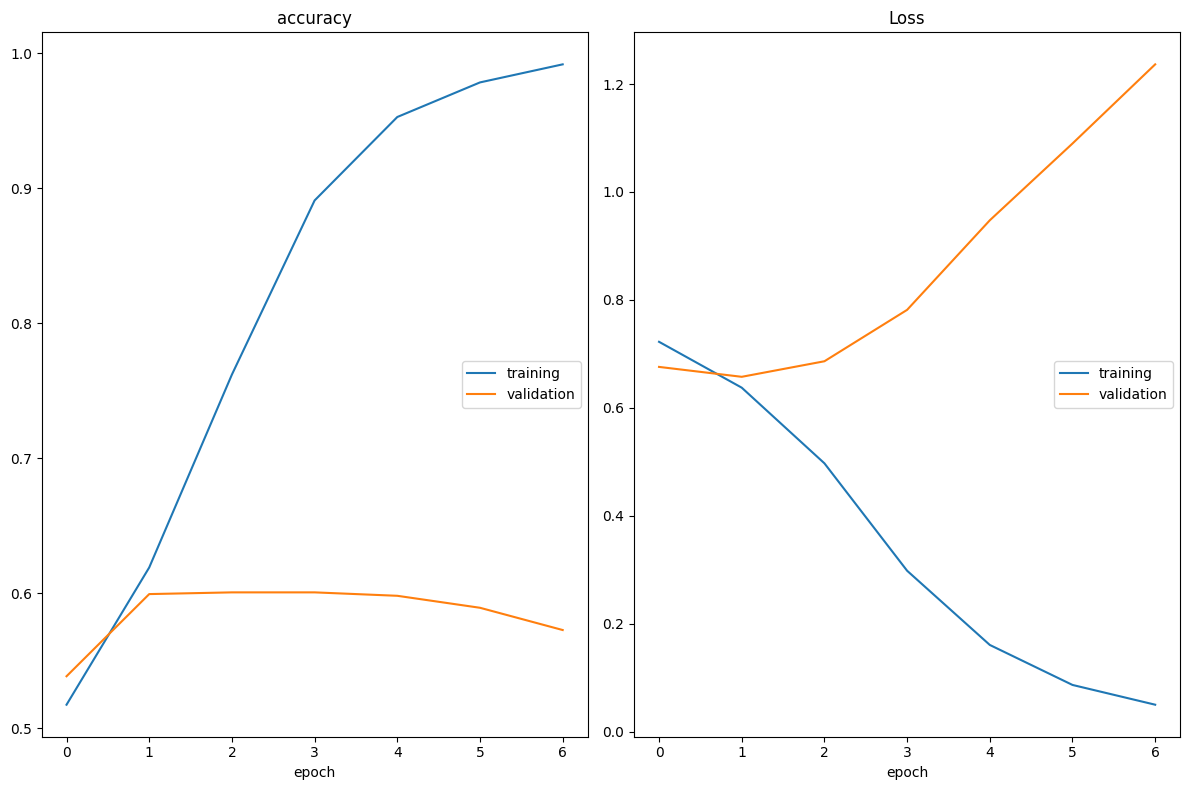

accuracy
	training         	 (min:    0.518, max:    0.992, cur:    0.992)
	validation       	 (min:    0.539, max:    0.601, cur:    0.573)
Loss
	training         	 (min:    0.050, max:    0.722, cur:    0.050)
	validation       	 (min:    0.658, max:    1.236, cur:    1.236)
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9919 - loss: 0.0528 - val_accuracy: 0.5729 - val_loss: 1.2364


Model: "sequential_60"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_60 (Embedding)        │ (None, 87, 256)        │     9,859,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_36 (Flatten)            │ (None, 22272)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_137 (Dense)               │ (None, 128)            │     2,850,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_138 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,131,973 (145.46 MB)

 Trainable params: 12,710,657 (48.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,421,316 (96.97 MB)

In [210]:
n_splits = 10
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_no = 1
acc_per_fold = []
loss_per_fold = []
histories = []

X_data = np.concatenate((X_train, X_test))
y_data = np.concatenate((y_train, y_test))

for train_idx, val_idx in kfold.split(X_data):
  print(f'Fold {fold_no}')

  X_train_fold, X_val_fold = X_data[train_idx], X_data[val_idx]
  y_train_fold, y_val_fold = y_data[train_idx], y_data[val_idx]

  model = Sequential()
  model.add(Embedding(vocab_size, 256, input_length=max_url_len))
  model.add(Flatten())
  model.add(Dense(128, activation='sigmoid'))
  model.add(Dropout(0.5))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

  early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

  history = model.fit(
      X_train_fold, y_train_fold,
      validation_data=(X_val_fold, y_val_fold),
      batch_size=128,
      epochs=50,
      verbose=1,
      callbacks=[PlotLossesKeras(), early_stopping]
  )

  histories.append(history)

  scores = model.evaluate(X_val_fold, y_val_fold, verbose=0)
  acc_per_fold.append(scores[1] * 100)
  loss_per_fold.append(scores[0])

  fold_no += 1

model.summary()

In [211]:
y_pred = (model.predict(X_test) > 0.5)[:,0].astype("int32")
print((y_pred == y_test).mean())

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
0.7707409753008233


# Exercise 6.3

Create a LSTM neural network to predict the rating of a movie

Calculate the testing set accuracy

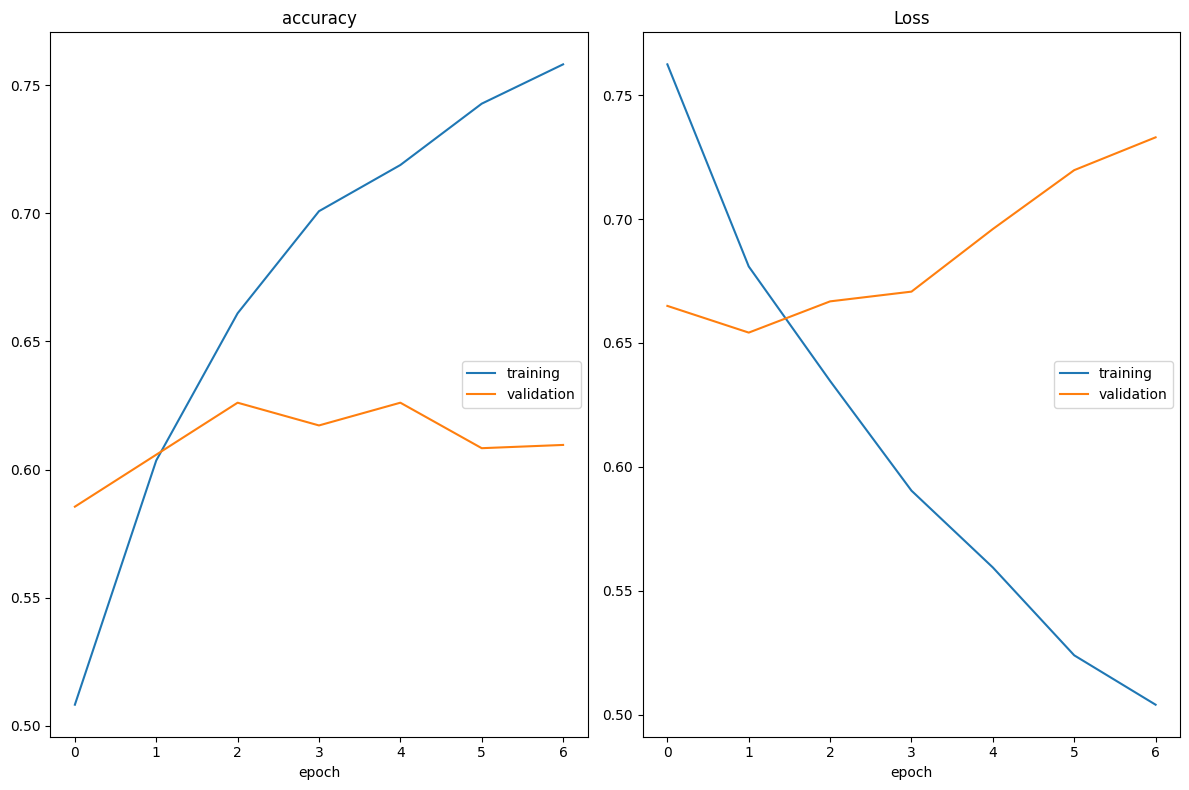

accuracy
	training         	 (min:    0.508, max:    0.758, cur:    0.758)
	validation       	 (min:    0.586, max:    0.626, cur:    0.610)
Loss
	training         	 (min:    0.504, max:    0.762, cur:    0.504)
	validation       	 (min:    0.654, max:    0.733, cur:    0.733)
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7580 - loss: 0.5050 - val_accuracy: 0.6096 - val_loss: 0.7330


Model: "sequential_120"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_120 (Embedding)       │ (None, 87, 256)        │     9,859,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_51 (LSTM)                  │ (None, 50)             │        61,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_257 (Dense)               │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_137 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_258 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,782,925 (113.61 MB)

 Trainable params: 9,927,641 (37.87 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,855,284 (75.74 MB)

In [222]:
n_splits = 10
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_no = 1
acc_per_fold = []
loss_per_fold = []
histories = []

X_data = np.concatenate((X_train, X_test))
y_data = np.concatenate((y_train, y_test))

for train_idx, val_idx in kfold.split(X_data):
  print(f'Fold {fold_no}')

  X_train_fold, X_val_fold = X_data[train_idx], X_data[val_idx]
  y_train_fold, y_val_fold = y_data[train_idx], y_data[val_idx]

  model = Sequential()
  model.add(Embedding(vocab_size, 256, input_length=max_url_len))
  model.add(LSTM(50))
  model.add(Dense(128, activation='sigmoid'))
  model.add(Dropout(0.5))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

  early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

  history = model.fit(
      X_train_fold, y_train_fold,
      validation_data=(X_val_fold, y_val_fold),
      batch_size=128,
      epochs=50,
      verbose=1,
      callbacks=[PlotLossesKeras(), early_stopping]
  )

  histories.append(history)

  scores = model.evaluate(X_val_fold, y_val_fold, verbose=0)
  acc_per_fold.append(scores[1] * 100)
  loss_per_fold.append(scores[0])

  fold_no += 1

model.summary()

In [223]:
y_pred = (model.predict(X_test) > 0.5)[:,0].astype("int32")
print((y_pred == y_test).mean())

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
0.6909436352121596


# Exercise 6.4

Create a GRU neural network to predict the rating of a movie

Calculate the testing set accuracy

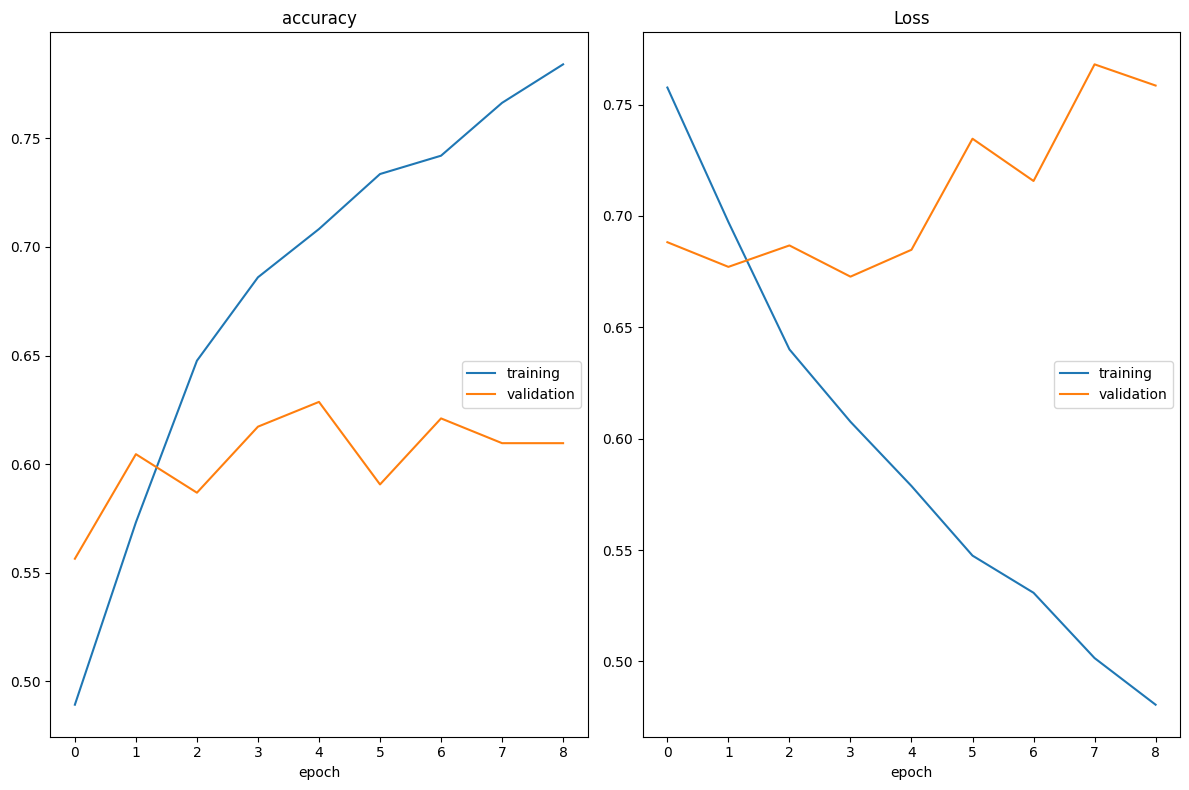

accuracy
	training         	 (min:    0.489, max:    0.784, cur:    0.784)
	validation       	 (min:    0.556, max:    0.629, cur:    0.610)
Loss
	training         	 (min:    0.481, max:    0.758, cur:    0.481)
	validation       	 (min:    0.673, max:    0.768, cur:    0.759)
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7897 - loss: 0.4711 - val_accuracy: 0.6096 - val_loss: 0.7585


Model: "sequential_90"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_90 (Embedding)        │ (None, 87, 256)        │     9,859,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_25 (GRU)                    │ (None, 45)             │        40,905 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_197 (Dense)               │ (None, 128)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_107 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_198 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,719,520 (113.37 MB)

 Trainable params: 9,906,506 (37.79 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,813,014 (75.58 MB)

In [216]:
n_splits = 10
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_no = 1
acc_per_fold = []
loss_per_fold = []
histories = []

X_data = np.concatenate((X_train, X_test))
y_data = np.concatenate((y_train, y_test))

for train_idx, val_idx in kfold.split(X_data):
  print(f'Fold {fold_no}')

  X_train_fold, X_val_fold = X_data[train_idx], X_data[val_idx]
  y_train_fold, y_val_fold = y_data[train_idx], y_data[val_idx]

  model = Sequential()
  model.add(Embedding(vocab_size, 256, input_length=max_url_len))
  model.add(GRU(45))
  model.add(Dense(128, activation='sigmoid'))
  model.add(Dropout(0.5))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

  early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

  history = model.fit(
      X_train_fold, y_train_fold,
      validation_data=(X_val_fold, y_val_fold),
      batch_size=128,
      epochs=50,
      verbose=1,
      callbacks=[PlotLossesKeras(), early_stopping]
  )

  histories.append(history)

  scores = model.evaluate(X_val_fold, y_val_fold, verbose=0)
  acc_per_fold.append(scores[1] * 100)
  loss_per_fold.append(scores[0])

  fold_no += 1

model.summary()

In [217]:
y_pred = (model.predict(X_test) > 0.5)[:,0].astype("int32")
print((y_pred == y_test).mean())

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
0.7200759974667511
